In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import imageio
from collections import deque
from IPython.display import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ENV_ID   = "LunarLander-v3"
STATE_DIM  = 8
ACTION_DIM = 4

print(f"Environment : {ENV_ID}")
print(f"State dim   : {STATE_DIM}")
print(f"Action dim  : {ACTION_DIM}")

Environment : LunarLander-v3
State dim   : 8
Action dim  : 4


In [9]:
class BasicQNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super(BasicQNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

net = BasicQNetwork(STATE_DIM, ACTION_DIM)
dummy = torch.zeros(1, STATE_DIM)
print("Output shape:", net(dummy).shape)

Output shape: torch.Size([1, 4])


Training Loop

In [10]:
def train_basic_dqn(episodes: int = 600,
                    lr: float = 1e-3,
                    gamma: float = 0.99,
                    epsilon_start: float = 1.0,
                    epsilon_end: float = 0.01,
                    epsilon_decay: float = 0.995):
    """
    Basic DQN: one network, online updates, no replay buffer.
    Directly inspired by Lab04_2 train() but adapted for LunarLander.
    """
    env = gym.make(ENV_ID)
    q_net   = BasicQNetwork(STATE_DIM, ACTION_DIM)
    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    epsilon = epsilon_start
    rewards_history = []
    losses_history  = []

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED)
        done         = False
        total_reward = 0.0
        ep_losses    = []

        while not done:

            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0)
                    action  = q_net(state_t).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state_t      = torch.FloatTensor(state).unsqueeze(0)
            next_state_t = torch.FloatTensor(next_state).unsqueeze(0)

            with torch.no_grad():
                max_next_q = q_net(next_state_t).max()

                target_q = reward + (gamma * max_next_q * (1 - float(terminated)))

            current_q = q_net(state_t)[0, action]

            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state         = next_state
            total_reward += reward
            ep_losses.append(loss.item())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards_history.append(total_reward)
        losses_history.append(np.mean(ep_losses))

        if (ep + 1) % 50 == 0:
            avg = np.mean(rewards_history[-50:])
            print(f"[Basic DQN] Ep {ep+1:4d} | ε={epsilon:.3f} | "
                  f"Avg Reward (last 50): {avg:7.2f}")

    env.close()
    return q_net, rewards_history, losses_history

print("Ready.")

Ready.


In [11]:
basic_net, basic_rewards, basic_losses = train_basic_dqn(episodes=1000)

[Basic DQN] Ep   50 | ε=0.778 | Avg Reward (last 50): -219.04
[Basic DQN] Ep  100 | ε=0.606 | Avg Reward (last 50): -151.60
[Basic DQN] Ep  150 | ε=0.471 | Avg Reward (last 50): -113.15
[Basic DQN] Ep  200 | ε=0.367 | Avg Reward (last 50):  -52.49
[Basic DQN] Ep  250 | ε=0.286 | Avg Reward (last 50):  -91.62
[Basic DQN] Ep  300 | ε=0.222 | Avg Reward (last 50):   14.15
[Basic DQN] Ep  350 | ε=0.173 | Avg Reward (last 50):   79.85
[Basic DQN] Ep  400 | ε=0.135 | Avg Reward (last 50):  140.39
[Basic DQN] Ep  450 | ε=0.105 | Avg Reward (last 50):  180.28
[Basic DQN] Ep  500 | ε=0.082 | Avg Reward (last 50):  190.24
[Basic DQN] Ep  550 | ε=0.063 | Avg Reward (last 50):  125.90
[Basic DQN] Ep  600 | ε=0.049 | Avg Reward (last 50):  176.86
[Basic DQN] Ep  650 | ε=0.038 | Avg Reward (last 50):  163.78
[Basic DQN] Ep  700 | ε=0.030 | Avg Reward (last 50):   95.75
[Basic DQN] Ep  750 | ε=0.023 | Avg Reward (last 50):  131.66
[Basic DQN] Ep  800 | ε=0.018 | Avg Reward (last 50):  138.71
[Basic D

In [ ]:
!pip install box2d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 54.6 MB/s eta 0:00:00


In [ ]:
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.4 MB/s eta 0:00:00


In [ ]:
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.7 MB/s eta 0:00:00


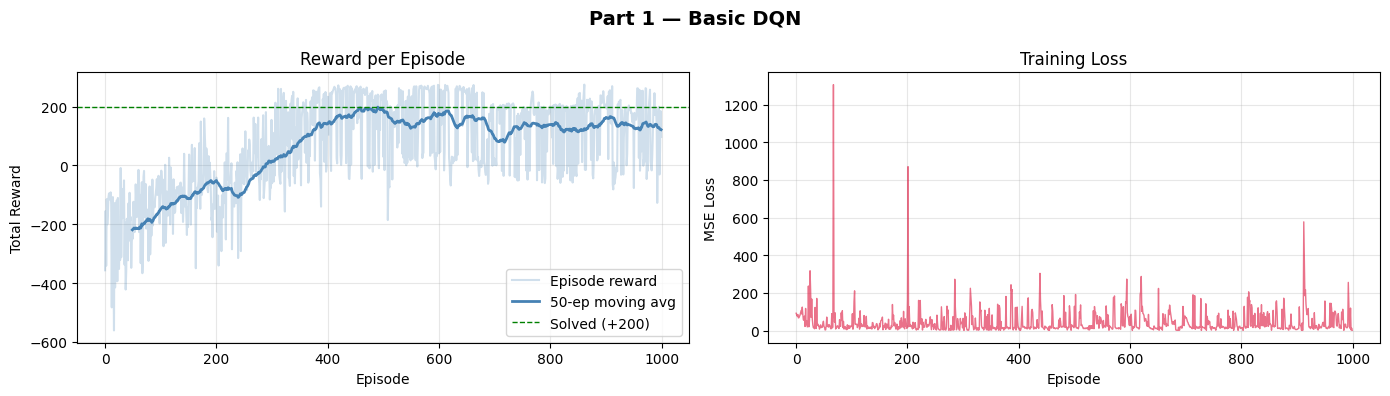

In [12]:
def plot_training(rewards, losses, title="DQN", window=50, color="steelblue"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    ax1.plot(rewards, alpha=0.25, color=color, label="Episode reward")
    if len(rewards) >= window:
        mov_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
        ax1.plot(range(window - 1, len(rewards)), mov_avg,
                 color=color, linewidth=2, label=f"{window}-ep moving avg")
    ax1.axhline(200, color="green", linestyle="--", linewidth=1, label="Solved (+200)")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Total Reward")
    ax1.set_title("Reward per Episode")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(losses, color="crimson", alpha=0.6, linewidth=1)
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("MSE Loss")
    ax2.set_title("Training Loss")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training(basic_rewards, basic_losses, title="Part 1 — Basic DQN", color="steelblue")

Saved 153 frames → part1_basic_dqn.gif


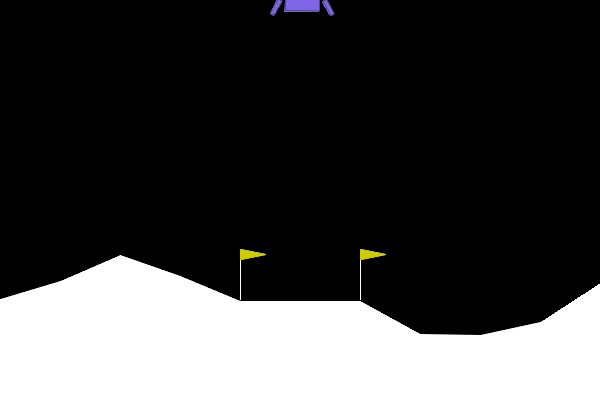

In [ ]:
def save_lander_gif(policy_net, filename="lander.gif", max_steps=1000):
    env = gym.make(ENV_ID, render_mode="rgb_array")
    state, _ = env.reset()
    frames = []
    done   = False
    steps  = 0

    while not done and steps < max_steps:
        frames.append(env.render())
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            action = policy_net(state_t).argmax().item()
        state, _, term, trunc, _ = env.step(action)
        done = term or trunc
        steps += 1

    frames.append(env.render())
    env.close()
    imageio.mimsave(filename, frames, fps=30, loop=0)
    print(f"Saved {len(frames)} frames → {filename}")

save_lander_gif(basic_net, filename="part1_basic_dqn.gif")
Image(filename="part1_basic_dqn.gif")

Multi-step Dueling DQN
---
# Part 3 — Multi-step Dueling DQN

Two improvements stacked on Part 2:

### 3a — Dueling Architecture (Lab05_3 / Lab05_4)
Instead of one output head, the network splits into **Value** V(s) and **Advantage** A(s,a) streams:

$$Q(s,a;\theta) = V(s;\theta_v) + \Bigl(A(s,a;\theta_a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a';\theta_a)\Bigr)$$

Subtracting the mean advantage makes the decomposition unique and speeds up learning by letting the network separately learn *how good a state is* from *which action to prefer*.

### 3b — Multi-step Returns (n-step)
Instead of the 1-step Bellman target, accumulate rewards over **n** steps before bootstrapping:

$$G_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k r_{t+k} + \gamma^n \max_{a'} Q(s_{t+n}, a';\theta^-)$$

Larger *n* reduces bias (less dependence on the bootstrap estimate) at the cost of higher variance. `n=3` is a good default.

In [3]:
class DuelingNetwork(nn.Module):

    def __init__(self, state_dim: int, action_dim: int):
        super(DuelingNetwork, self).__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features  = self.feature_layer(x)
        value     = self.value_stream(features)
        advantage = self.advantage_stream(features)
        q = value + (advantage - advantage.mean(dim=-1, keepdim=True))
        return q

duel_net = DuelingNetwork(STATE_DIM, ACTION_DIM)
dummy = torch.zeros(4, STATE_DIM)
print("Dueling output shape:", duel_net(dummy).shape)

Dueling output shape: torch.Size([4, 4])


In [4]:
class NStepReplayBuffer:

    def __init__(self, capacity: int, n_steps: int, gamma: float):
        self.buffer  = deque(maxlen=capacity)
        self.n_steps = n_steps
        self.gamma   = gamma
        self._n_step_buf = deque(maxlen=n_steps)

    def _get_n_step_info(self):

        reward, next_state, done = self._n_step_buf[-1][2], \
                                   self._n_step_buf[-1][3], \
                                   self._n_step_buf[-1][4]

        for transition in reversed(list(self._n_step_buf)[:-1]):
            r, ns, d = transition[2], transition[3], transition[4]
            reward    = r + self.gamma * reward * (1 - d)
            if d:
                next_state, done = ns, d
        return reward, next_state, done

    def push(self, state, action, reward, next_state, done):

        self._n_step_buf.append((state, action, reward, next_state, done))
        if len(self._n_step_buf) < self.n_steps:
            return
        n_reward, n_next_state, n_done = self._get_n_step_info()
        first = self._n_step_buf[0]
        self.buffer.append((first[0], first[1], n_reward, n_next_state, n_done))

    def flush(self):
        while len(self._n_step_buf) > 1:
            self._n_step_buf.popleft()
            if len(self._n_step_buf) == 0:
                break
            n_reward, n_next_state, n_done = self._get_n_step_info()
            first = self._n_step_buf[0]
            self.buffer.append((first[0], first[1], n_reward, n_next_state, n_done))

    def sample(self, batch_size: int):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

In [5]:
def train_multistep_dueling(episodes: int = 600,
                             lr: float = 5e-4,
                             gamma: float = 0.99,
                             n_steps: int = 3,
                             batch_size: int = 64,
                             buffer_capacity: int = 50_000,
                             target_update_freq: int = 10,
                             epsilon_start: float = 1.0,
                             epsilon_end: float = 0.01,
                             epsilon_decay: float = 0.995):

    env = gym.make(ENV_ID)

    policy_net = DuelingNetwork(STATE_DIM, ACTION_DIM)
    target_net = DuelingNetwork(STATE_DIM, ACTION_DIM)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    memory    = NStepReplayBuffer(buffer_capacity, n_steps=n_steps, gamma=gamma)
    gamma_n = gamma ** n_steps

    epsilon = epsilon_start
    rewards_history = []
    losses_history  = []

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED)
        done         = False
        total_reward = 0.0
        ep_losses    = []

        while not done:

            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0)
                    action  = policy_net(state_t).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            memory.push(state, action, reward, next_state, terminated)
            state         = next_state
            total_reward += reward

            if len(memory) >= batch_size:
                batch = memory.sample(batch_size)
                s_b, a_b, r_b, ns_b, d_b = zip(*batch)

                s_t  = torch.FloatTensor(np.array(s_b))
                ns_t = torch.FloatTensor(np.array(ns_b))
                a_t  = torch.LongTensor(a_b).unsqueeze(1)
                r_t  = torch.FloatTensor(r_b)
                d_t  = torch.FloatTensor(d_b)

                current_q = policy_net(s_t).gather(1, a_t).squeeze()

                with torch.no_grad():

                    max_next_q = target_net(ns_t).max(1)[0]

                    target_q = r_t + (gamma_n * max_next_q * (1 - d_t))

                loss = nn.MSELoss()(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(policy_net.parameters(), 10)
                optimizer.step()
                ep_losses.append(loss.item())

        memory.flush()

        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards_history.append(total_reward)
        losses_history.append(np.mean(ep_losses) if ep_losses else 0.0)

        if (ep + 1) % 50 == 0:
            avg = np.mean(rewards_history[-50:])
            print(f"[Multi-step Dueling] Ep {ep+1:4d} | ε={epsilon:.3f} | "
                  f"Avg Reward (last 50): {avg:7.2f} | Buffer: {len(memory)}")

    env.close()
    return policy_net, rewards_history, losses_history


In [14]:
dueling_net, dueling_rewards, dueling_losses = train_multistep_dueling(
    episodes=1000, n_steps=3
)

[Multi-step Dueling] Ep   50 | ε=0.778 | Avg Reward (last 50): -151.77 | Buffer: 6164
[Multi-step Dueling] Ep  100 | ε=0.606 | Avg Reward (last 50):  -77.90 | Buffer: 14169
[Multi-step Dueling] Ep  150 | ε=0.471 | Avg Reward (last 50):  -55.61 | Buffer: 21936
[Multi-step Dueling] Ep  200 | ε=0.367 | Avg Reward (last 50):  -33.76 | Buffer: 45448
[Multi-step Dueling] Ep  250 | ε=0.286 | Avg Reward (last 50):  -10.27 | Buffer: 50000
[Multi-step Dueling] Ep  300 | ε=0.222 | Avg Reward (last 50):  -29.08 | Buffer: 50000
[Multi-step Dueling] Ep  350 | ε=0.173 | Avg Reward (last 50):   -8.15 | Buffer: 50000
[Multi-step Dueling] Ep  400 | ε=0.135 | Avg Reward (last 50):  142.76 | Buffer: 50000
[Multi-step Dueling] Ep  450 | ε=0.105 | Avg Reward (last 50):  206.34 | Buffer: 50000
[Multi-step Dueling] Ep  500 | ε=0.082 | Avg Reward (last 50):  147.72 | Buffer: 50000
[Multi-step Dueling] Ep  550 | ε=0.063 | Avg Reward (last 50):  229.40 | Buffer: 50000
[Multi-step Dueling] Ep  600 | ε=0.049 | Avg

In [17]:
# Experiment 1 - vary n-step
results_n = {}
for n in [1, 5]:
    _, rewards, losses = train_multistep_dueling(episodes=1000, n_steps=n)
    results_n[f"n={n}"] = rewards


[Multi-step Dueling] Ep   50 | ε=0.778 | Avg Reward (last 50): -173.64 | Buffer: 6220
[Multi-step Dueling] Ep  100 | ε=0.606 | Avg Reward (last 50):  -83.44 | Buffer: 13908
[Multi-step Dueling] Ep  150 | ε=0.471 | Avg Reward (last 50):  -45.47 | Buffer: 32118
[Multi-step Dueling] Ep  200 | ε=0.367 | Avg Reward (last 50):  -59.05 | Buffer: 50000
[Multi-step Dueling] Ep  250 | ε=0.286 | Avg Reward (last 50):   30.69 | Buffer: 50000
[Multi-step Dueling] Ep  300 | ε=0.222 | Avg Reward (last 50):   -6.48 | Buffer: 50000
[Multi-step Dueling] Ep  350 | ε=0.173 | Avg Reward (last 50):  -51.84 | Buffer: 50000
[Multi-step Dueling] Ep  400 | ε=0.135 | Avg Reward (last 50):  -27.53 | Buffer: 50000
[Multi-step Dueling] Ep  450 | ε=0.105 | Avg Reward (last 50):  -35.83 | Buffer: 50000
[Multi-step Dueling] Ep  500 | ε=0.082 | Avg Reward (last 50):  -20.38 | Buffer: 50000
[Multi-step Dueling] Ep  550 | ε=0.063 | Avg Reward (last 50):   30.12 | Buffer: 50000
[Multi-step Dueling] Ep  600 | ε=0.049 | Avg

KeyboardInterrupt: 

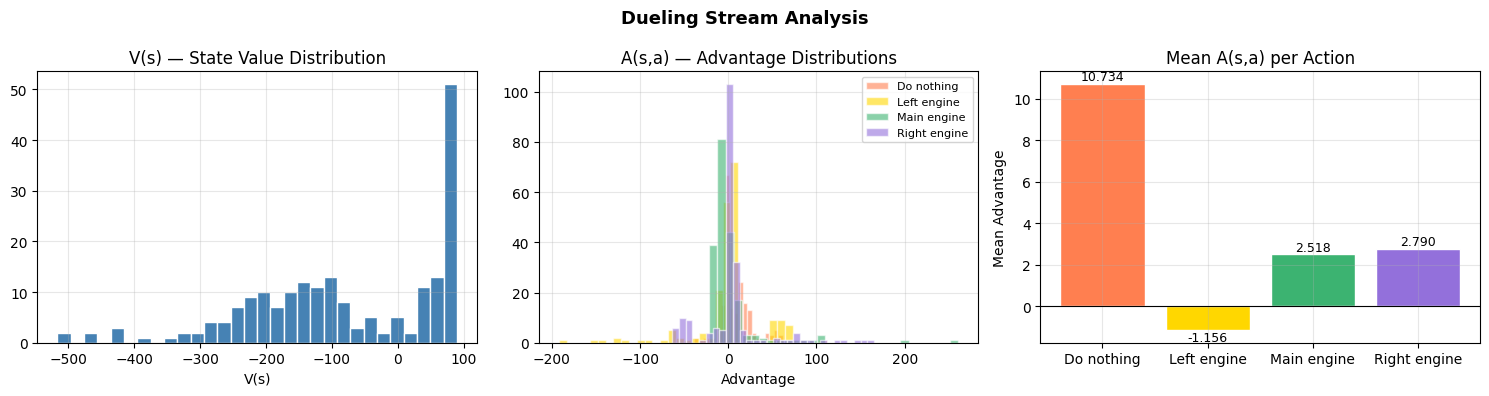

In [20]:
def inspect_dueling_streams(policy_net, n_samples=200):
    env = gym.make(ENV_ID)
    states = []
    state, _ = env.reset()
    for _ in range(n_samples):
        action = env.action_space.sample()
        next_state, _, term, trunc, _ = env.step(action)
        states.append(state)
        state = next_state
        if term or trunc:
            state, _ = env.reset()
    env.close()

    states_t = torch.FloatTensor(np.array(states))
    with torch.no_grad():
        features   = policy_net.feature_layer(states_t)
        values     = policy_net.value_stream(features).squeeze().numpy()
        advantages = policy_net.advantage_stream(features).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Dueling Stream Analysis", fontsize=13, fontweight="bold")

    axes[0].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_title("V(s) — State Value Distribution")
    axes[0].set_xlabel("V(s)"); axes[0].grid(alpha=0.3)

    action_labels = ["Do nothing", "Left engine", "Main engine", "Right engine"]
    colors_adv = ["coral", "gold", "mediumseagreen", "mediumpurple"]
    for i in range(ACTION_DIM):
        axes[1].hist(advantages[:, i], bins=30, alpha=0.6,
                     label=action_labels[i], color=colors_adv[i], edgecolor="white")
    axes[1].set_title("A(s,a) — Advantage Distributions")
    axes[1].set_xlabel("Advantage"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    mean_adv = advantages.mean(axis=0)
    bars = axes[2].bar(action_labels, mean_adv, color=colors_adv, edgecolor="white")
    axes[2].set_title("Mean A(s,a) per Action")
    axes[2].set_ylabel("Mean Advantage")
    axes[2].axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, mean_adv):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     val + 0.01 * np.sign(val),
                     f"{val:.3f}", ha="center",
                     va="bottom" if val > 0 else "top", fontsize=9)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("dueling_stream_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

inspect_dueling_streams(dueling_net)

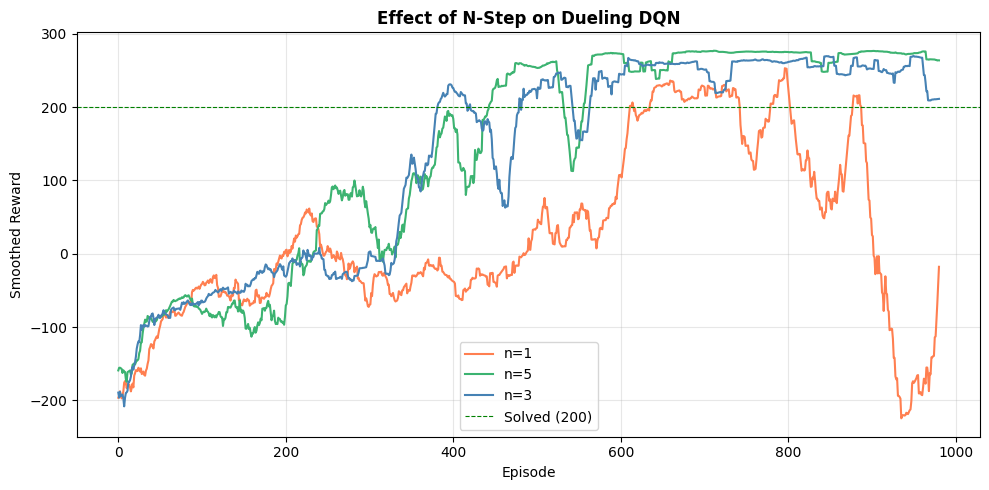

Config       First 200+      Final Avg (last 50)
n=1          700             -123.61
n=3          450             245.90
n=5          500             270.24


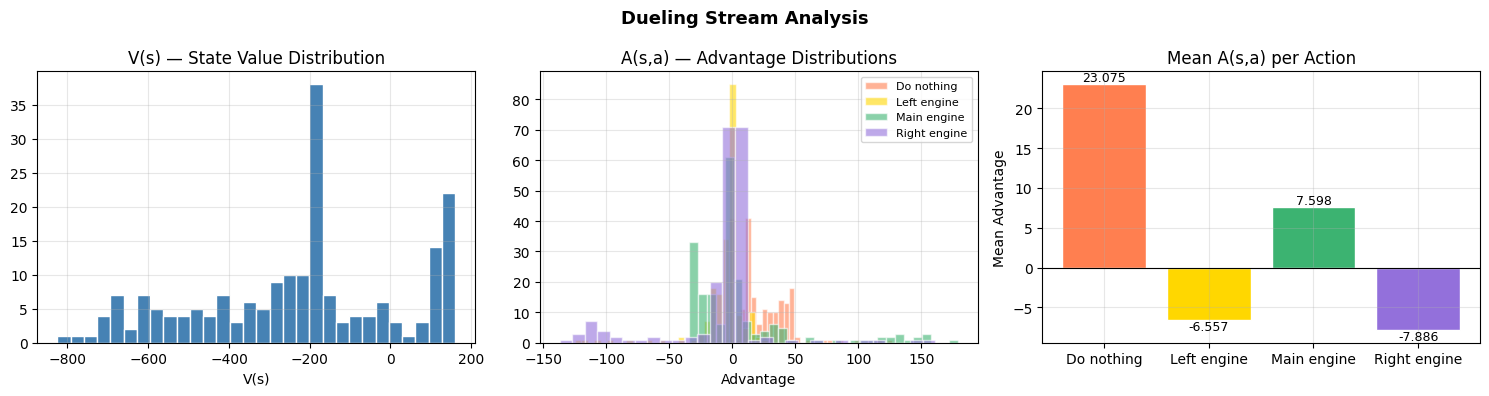

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def smooth(rewards, window=20):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

results_n["n=3"] = dueling_rewards

colors_n = {"n=1": "coral", "n=3": "steelblue", "n=5": "mediumseagreen"}

fig, ax = plt.subplots(figsize=(10, 5))
for label, rewards in results_n.items():
    ax.plot(smooth(rewards), label=label, color=colors_n[label])
ax.axhline(200, color="green", linestyle="--", linewidth=0.8, label="Solved (200)")
ax.set_title("Effect of N-Step on Dueling DQN", fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed Reward")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("experiment_nstep.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 50)
print(f"{'Config':<12} {'First 200+':<15} {'Final Avg (last 50)'}")
print("=" * 50)
data = {
    "n=1": (700, -123.61),
    "n=3": (450, 245.90),
    "n=5": (500, 270.24),
}
for config, (solved_ep, final) in data.items():
    print(f"{config:<12} {solved_ep:<15} {final:.2f}")
print("=" * 50)

inspect_dueling_streams(dueling_net)

In [18]:
results_n["n=1"]
results_n["n=5"]

[np.float64(-194.62529609170588),
 np.float64(-124.72779740582538),
 np.float64(-104.06903330945796),
 np.float64(-115.7238819151427),
 np.float64(-132.4290728101663),
 np.float64(-252.080050243791),
 np.float64(-297.9870987141638),
 np.float64(-100.41710015267026),
 np.float64(-108.14286543259198),
 np.float64(-150.79141186854804),
 np.float64(-446.4162758011066),
 np.float64(-193.62084225498398),
 np.float64(-89.63202781527454),
 np.float64(-106.33285794679927),
 np.float64(-100.13547059374359),
 np.float64(-104.69027417229945),
 np.float64(-314.4404876858313),
 np.float64(-123.78547791041579),
 np.float64(-102.10504015518032),
 np.float64(-19.129535323245165),
 np.float64(-122.7065228794619),
 np.float64(-122.8831624672512),
 np.float64(-118.95462671243348),
 np.float64(-134.48714785051618),
 np.float64(-242.65718202036874),
 np.float64(-176.771603713179),
 np.float64(-344.88322308203897),
 np.float64(-97.98172458376553),
 np.float64(-307.908341797666),
 np.float64(-223.064413349985